# 01. EDA (탐색적 데이터 분석)
**데이터셋**: Cardiovascular Disease Dataset (Kaggle, 70,000명)  
**목적**: 심혈관 위험도 예측 모델 학습 전 데이터 구조 및 분포 파악  
**참고 논문**: XGBoost 기반 K-Means 군집 분석을 활용한 심장질환 예측 (한국정보전자통신기술학회, 2025)

In [39]:
# ── 셀 1: 라이브러리 import + 환경 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
print('import 완료!')

import 완료!


In [40]:
# ── 셀 2: 데이터 로드 및 기본 확인
df = pd.read_csv('/Users/admin/cardiovascular_ml/data/cardio_train.csv', sep=';')

print(f'데이터 크기: {df.shape}')
print(f'컬럼 목록: {df.columns.tolist()}')
print(f'\n결측치:')
print(df.isnull().sum())
df.head()

데이터 크기: (70000, 13)
컬럼 목록: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

결측치:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [41]:
# ── 셀 3: 나이 변환 (일 → 세) + BMI 파생 변수
# 원본 age는 일(days) 단위 → 세(years)로 변환
df['age'] = (df['age'] / 365).astype(int)
print(f'나이 범위: {df["age"].min()}세 ~ {df["age"].max()}세')

# BMI 파생 변수 생성
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
print(f'BMI 범위: {df["bmi"].min():.2f} ~ {df["bmi"].max():.2f}')

print('\n기초 통계:')
df.describe().round(2)

나이 범위: 29세 ~ 64세
BMI 범위: 3.47 ~ 298.67

기초 통계:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0,70000.00
mean,49972.42,52.84,1.35,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5,27.56
std,28851.30,6.77,0.48,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5,6.09
min,0.00,29.00,1.00,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0,3.47
25%,25006.75,48.00,1.00,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,23.88
50%,50001.50,53.00,1.00,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0,26.37
75%,74889.25,58.00,2.00,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0,30.22
max,99999.00,64.00,2.00,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0,298.67


In [42]:
# ── 셀 4: 타겟 분포 확인
# 심혈관 질환 있는 사람 vs 없는 사람 비율
print('=== 타겟(cardio) 분포 ===')
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True).round(3))
# → 50:50에 가까울수록 균형 잡힌 데이터

=== 타겟(cardio) 분포 ===
cardio
0    35021
1    34979
Name: count, dtype: int64
cardio
0    0.5
1    0.5
Name: proportion, dtype: float64


In [43]:
# ── 셀 5: 이상치 탐지 (IQR 방법)
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f'{column}: 이상치 {len(outliers)}개 ({len(outliers)/len(df)*100:.1f}%)')
    print(f'  정상 범위: {lower:.1f} ~ {upper:.1f}')

num_features = ['ap_hi', 'ap_lo', 'bmi', 'age', 'height', 'weight']
print('=== IQR 이상치 탐지 ===')
for feat in num_features:
    detect_outliers_iqr(df, feat)

=== IQR 이상치 탐지 ===
ap_hi: 이상치 1435개 (2.1%)
  정상 범위: 90.0 ~ 170.0
ap_lo: 이상치 4632개 (6.6%)
  정상 범위: 65.0 ~ 105.0
bmi: 이상치 1995개 (2.9%)
  정상 범위: 14.4 ~ 39.7
age: 이상치 4개 (0.0%)
  정상 범위: 33.0 ~ 73.0
height: 이상치 519개 (0.7%)
  정상 범위: 142.5 ~ 186.5
weight: 이상치 1819개 (2.6%)
  정상 범위: 39.5 ~ 107.5


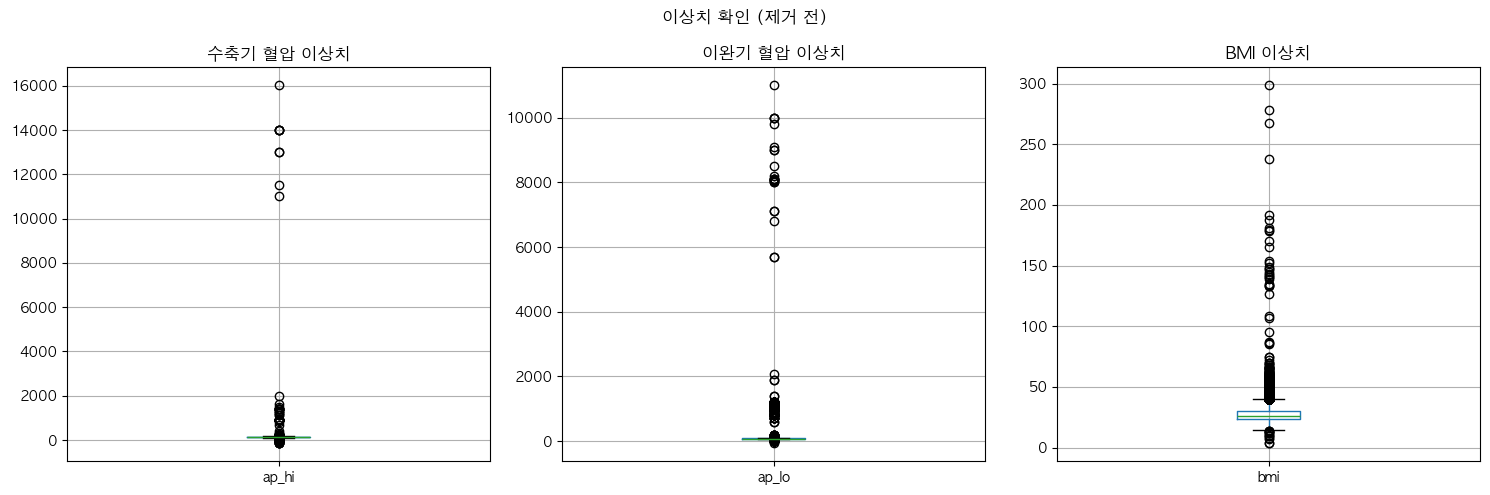

In [44]:
# ── 셀 6: 이상치 시각화 (제거 전)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column='ap_hi', ax=axes[0])
axes[0].set_title('수축기 혈압 이상치')

df.boxplot(column='ap_lo', ax=axes[1])
axes[1].set_title('이완기 혈압 이상치')

df.boxplot(column='bmi', ax=axes[2])
axes[2].set_title('BMI 이상치')

plt.suptitle('이상치 확인 (제거 전)')
plt.tight_layout()
plt.show()

In [45]:
# ── 셀 7: 이상치 제거 (의학적 정상 범위 기준)
# 02_preprocessing.ipynb와 동일한 기준 적용
before = len(df)
df_clean = df[
    (df['ap_hi'] >= 80)   & (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 50)   & (df['ap_lo'] <= 200) &
    (df['height'] >= 140) & (df['height'] <= 210) &
    (df['weight'] >= 40)  & (df['weight'] <= 180) &
    (df['bmi'] >= 10)     & (df['bmi'] <= 60)
]
after = len(df_clean)
print(f'이상치 제거 전: {before}명')
print(f'이상치 제거 후: {after}명')
print(f'제거된 행 수: {before - after}명')

이상치 제거 전: 70000명
이상치 제거 후: 68531명
제거된 행 수: 1469명


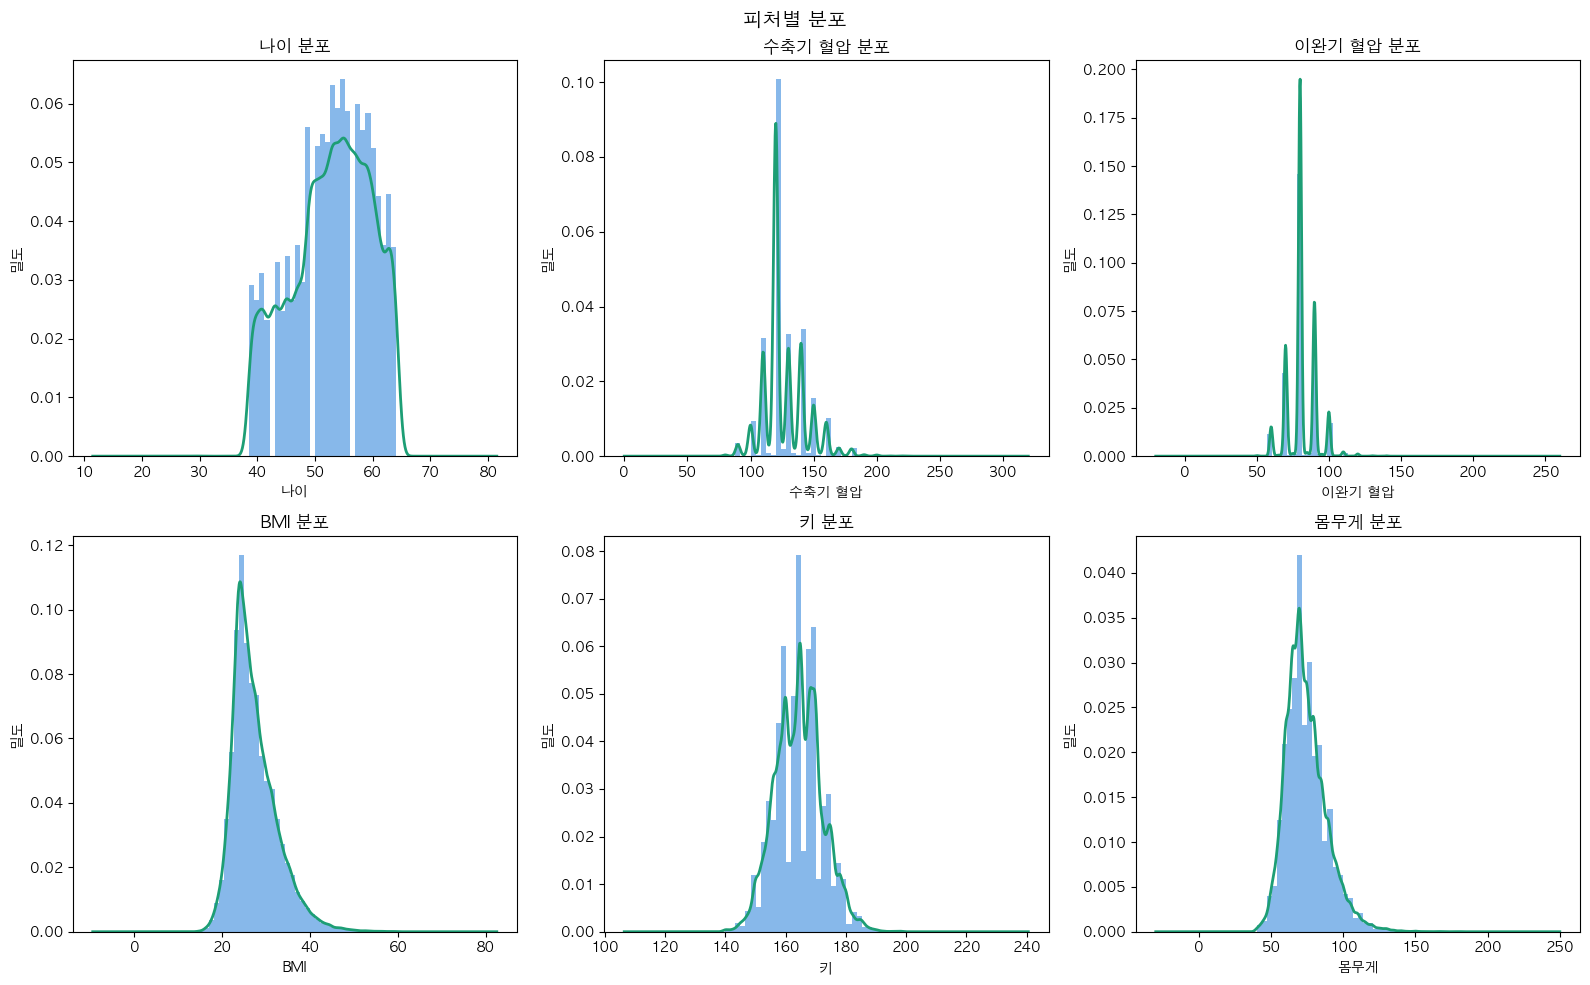

In [46]:
# ── 셀 8: 피처별 분포 시각화
features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'height', 'weight']
labels   = ['나이', '수축기 혈압', '이완기 혈압', 'BMI', '키', '몸무게']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    axes[i].hist(df_clean[feat], bins=40,
                 alpha=0.6, color='#378ADD',
                 density=True, label='전체')
    df_clean[feat].plot.kde(ax=axes[i],
                             color='#1D9E75', linewidth=2)
    axes[i].set_title(f'{label} 분포')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('밀도')

plt.suptitle('피처별 분포', fontsize=14)
plt.tight_layout()
plt.show()

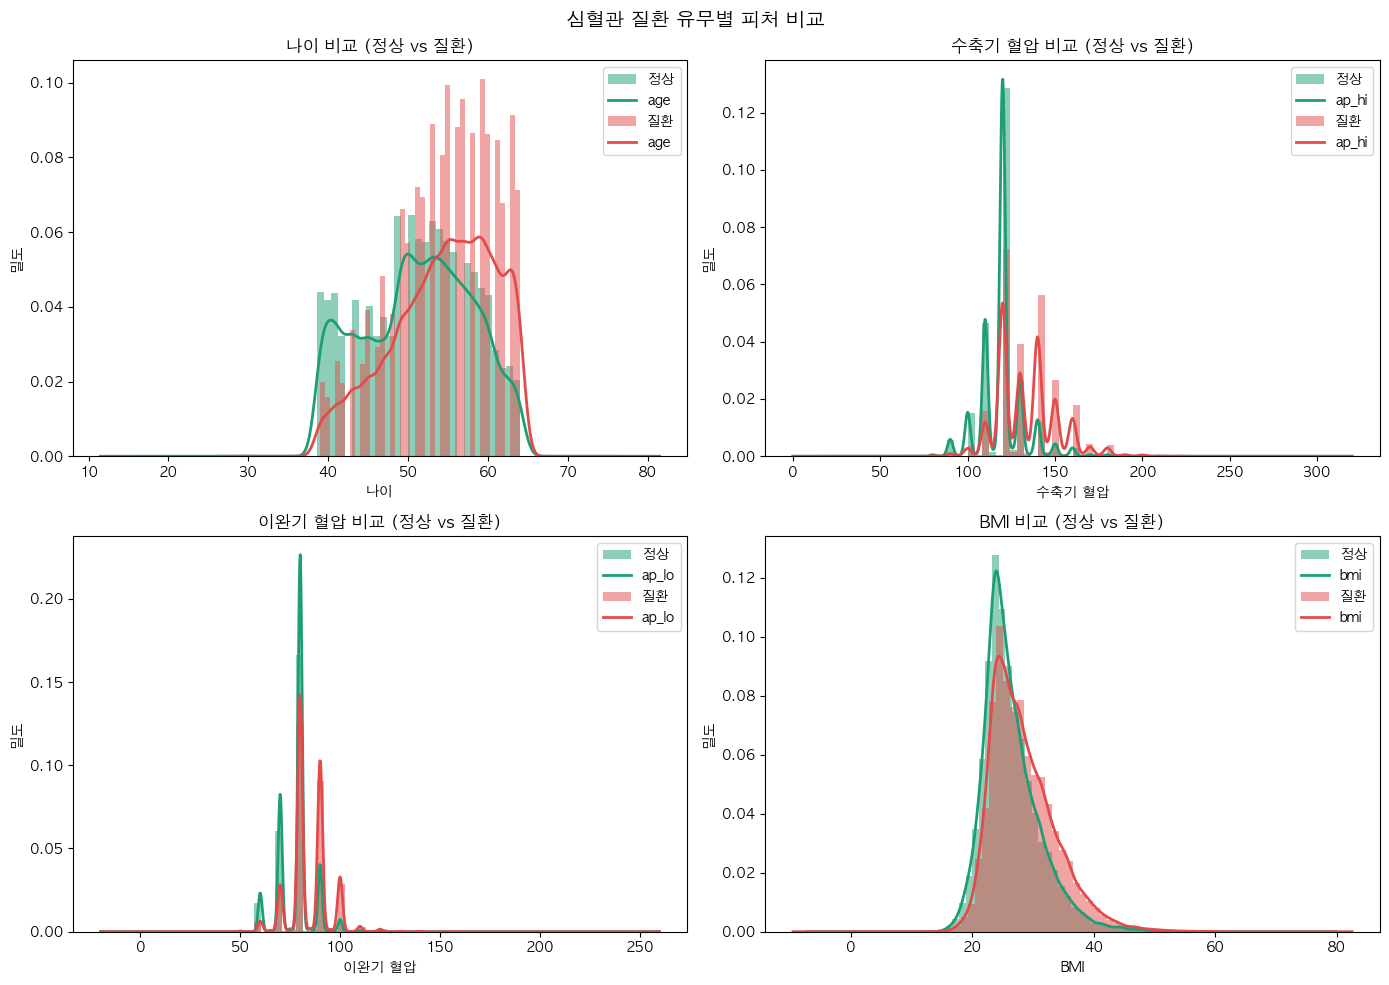

In [47]:
# ── 셀 9: 심혈관 질환 유무별 피처 비교
df_normal  = df_clean[df_clean['cardio'] == 0]
df_disease = df_clean[df_clean['cardio'] == 1]

features = ['age', 'ap_hi', 'ap_lo', 'bmi']
labels   = ['나이', '수축기 혈압', '이완기 혈압', 'BMI']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    axes[i].hist(df_normal[feat], bins=40, alpha=0.5,
                 color='#1D9E75', density=True, label='정상')
    df_normal[feat].plot.kde(ax=axes[i], color='#1D9E75', linewidth=2)
    axes[i].hist(df_disease[feat], bins=40, alpha=0.5,
                 color='#E24B4A', density=True, label='질환')
    df_disease[feat].plot.kde(ax=axes[i], color='#E24B4A', linewidth=2)
    axes[i].set_title(f'{label} 비교 (정상 vs 질환)')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('밀도')
    axes[i].legend()

plt.suptitle('심혈관 질환 유무별 피처 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
# ── 셀 10: 정상 vs 질환 평균값 비교
print('=== 심혈관 질환 유무별 평균값 비교 ===')
compare_features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']
compare_labels   = ['나이', '수축기혈압', '이완기혈압', 'BMI', '콜레스테롤', '혈당']

print(f'{"피처":<12} {"정상":>10} {"질환":>10} {"차이":>10}')
print('-' * 45)
for feat, label in zip(compare_features, compare_labels):
    normal_mean  = df_normal[feat].mean()
    disease_mean = df_disease[feat].mean()
    diff = disease_mean - normal_mean
    print(f'{label:<12} {normal_mean:>10.2f} {disease_mean:>10.2f} {diff:>+10.2f}')

=== 심혈관 질환 유무별 평균값 비교 ===
피처                   정상         질환         차이
---------------------------------------------
나이                51.22      54.46      +3.24
수축기혈압            119.60     133.82     +14.22
이완기혈압             78.18      84.68      +6.49
BMI               26.45      28.44      +1.99
콜레스테롤              1.22       1.52      +0.30
혈당                 1.18       1.28      +0.10


In [49]:
# ── 셀 11: 상관관계 분석
# cardio와 각 피처의 상관관계
correlation = df_clean.corr()['cardio'].sort_values(ascending=False)
print('=== cardio와 상관관계 (높은 순) ===')
print(correlation.round(3))

=== cardio와 상관관계 (높은 순) ===
cardio         1.000
ap_hi          0.425
ap_lo          0.337
age            0.239
cholesterol    0.221
bmi            0.193
weight         0.181
gluc           0.090
gender         0.007
id             0.003
alco          -0.008
height        -0.013
smoke         -0.016
active        -0.038
Name: cardio, dtype: float64


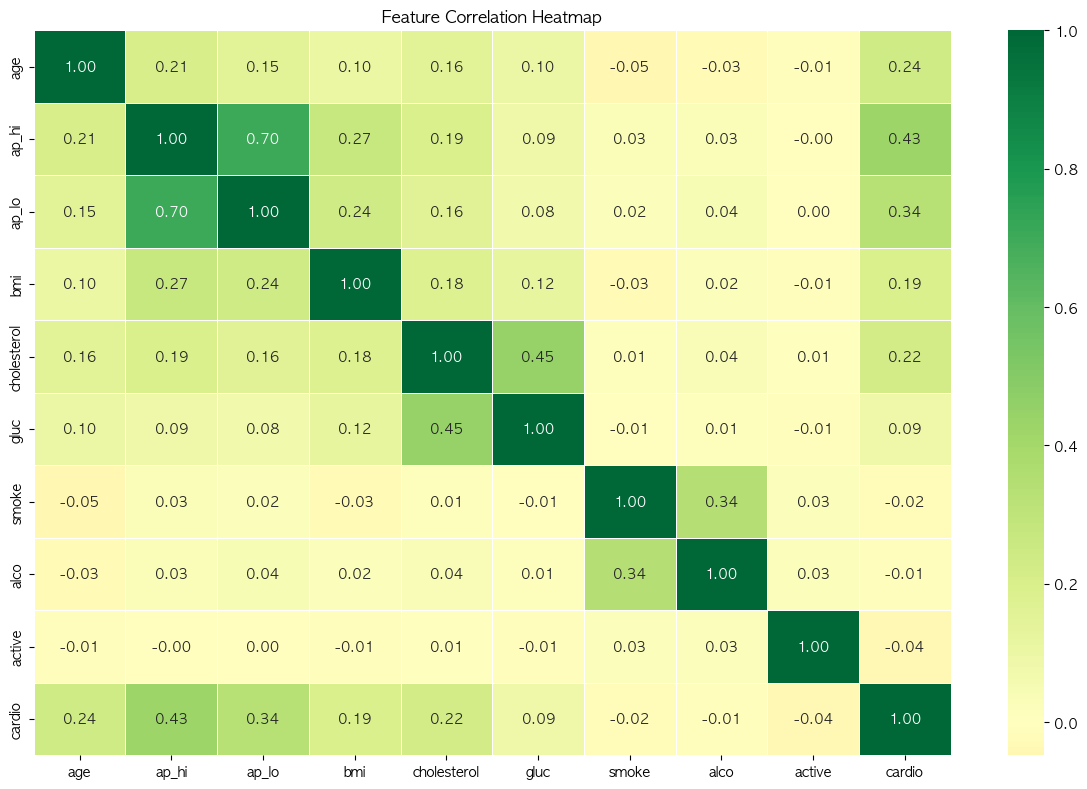

In [50]:
# ── 셀 12: 상관관계 히트맵
plt.figure(figsize=(12, 8))
corr = df_clean[['age', 'ap_hi', 'ap_lo', 'bmi',
                  'cholesterol', 'gluc', 'smoke',
                  'alco', 'active', 'cardio']].corr()

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

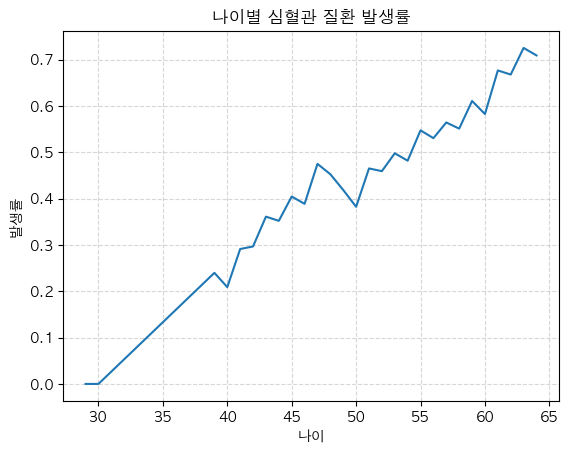

In [51]:
# ── 셀 13: 나이별 심혈관 질환 발생률
df_clean.groupby('age')['cardio'].mean().plot()
plt.title('나이별 심혈관 질환 발생률')
plt.xlabel('나이')
plt.ylabel('발생률')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [52]:
# ── 셀 14: 흡연·음주 분포 및 심혈관 위험 비율
print('=== 흡연 분포 ===')
print(df_clean['smoke'].value_counts())
print(f'흡연율: {df_clean["smoke"].mean():.3f} ({df_clean["smoke"].mean()*100:.1f}%)')

print('\n=== 음주 분포 ===')
print(df_clean['alco'].value_counts())
print(f'음주율: {df_clean["alco"].mean():.3f} ({df_clean["alco"].mean()*100:.1f}%)')

print('\n=== 흡연별 심혈관 질환 비율 ===')
print(df_clean.groupby('smoke')['cardio'].mean().round(3))

print('\n=== 음주별 심혈관 질환 비율 ===')
print(df_clean.groupby('alco')['cardio'].mean().round(3))

=== 흡연 분포 ===
smoke
0    62494
1     6037
Name: count, dtype: int64
흡연율: 0.088 (8.8%)

=== 음주 분포 ===
alco
0    64856
1     3675
Name: count, dtype: int64
음주율: 0.054 (5.4%)

=== 흡연별 심혈관 질환 비율 ===
smoke
0    0.498
1    0.469
Name: cardio, dtype: float64

=== 음주별 심혈관 질환 비율 ===
alco
0    0.496
1    0.479
Name: cardio, dtype: float64


In [53]:
# ── 셀 15: EDA 요약
print('=' * 40)
print('EDA 요약')
print('=' * 40)
print(f'원본 데이터:   70,000명')
print(f'이상치 제거 후: {after}명')
print(f'피처 수:       {df_clean.shape[1]}개')
print()
print('주요 발견')
print('→ cardio와 상관관계 1위: ap_hi (수축기 혈압)')
print('→ 질환자 평균 나이 > 정상자 평균 나이')
print('→ 흡연자 8.8% / 음주자 5.3% → 샘플 불균형')
print('→ 타겟 비율: 정상 50.5% / 질환 49.5% (균형)')
print()
print('→ 다음 단계: 02_preprocessing.ipynb')

EDA 요약
원본 데이터:   70,000명
이상치 제거 후: 68531명
피처 수:       14개

주요 발견
→ cardio와 상관관계 1위: ap_hi (수축기 혈압)
→ 질환자 평균 나이 > 정상자 평균 나이
→ 흡연자 8.8% / 음주자 5.3% → 샘플 불균형
→ 타겟 비율: 정상 50.5% / 질환 49.5% (균형)

→ 다음 단계: 02_preprocessing.ipynb
